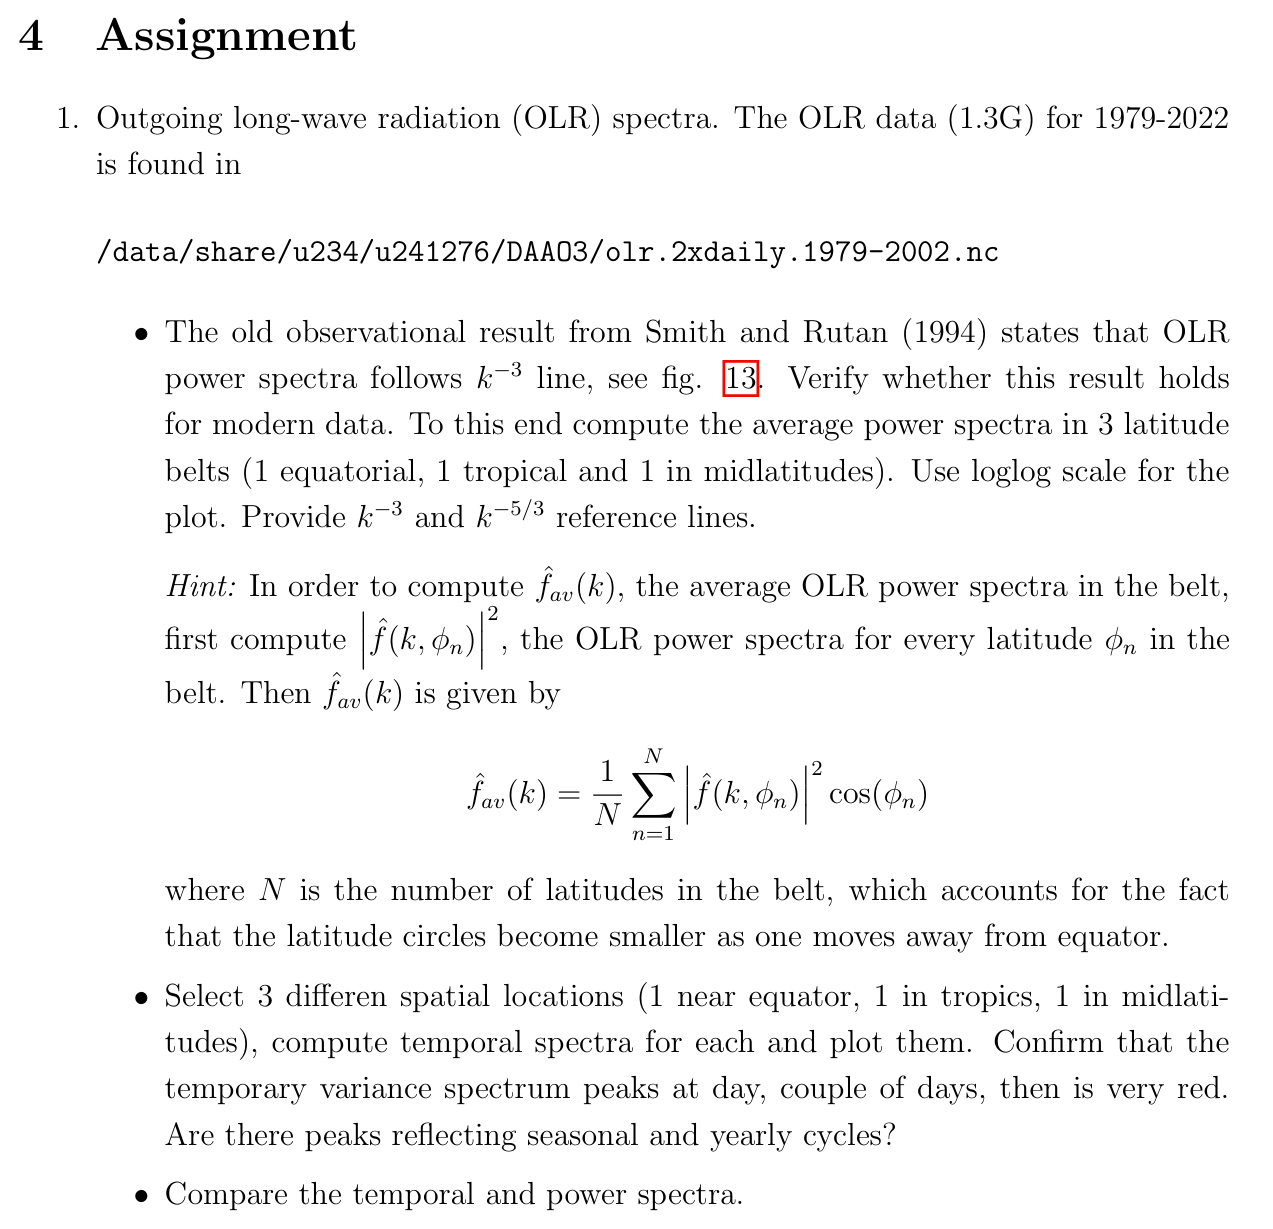

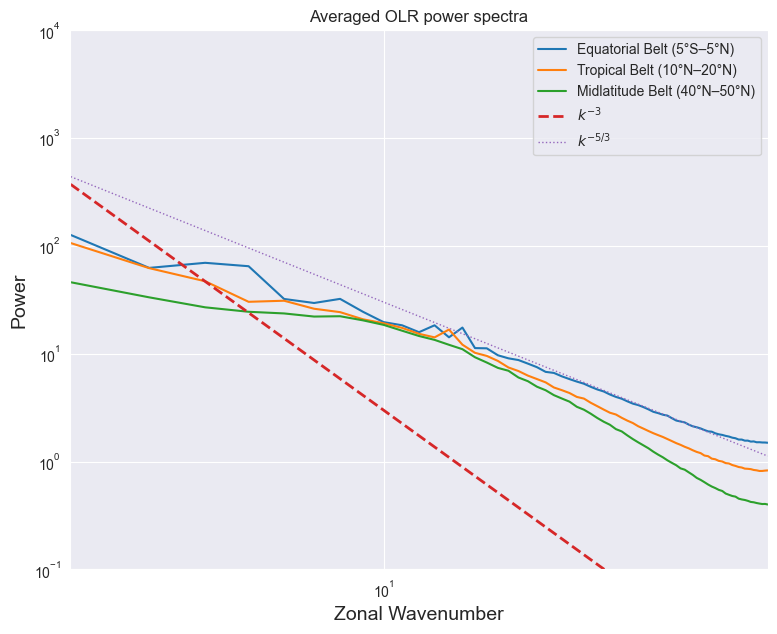

In [69]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.fft as fft
import xarray as xr


path = Path("olr.2xdaily.1979-2022.nc")

ds = xr.open_dataset(path, engine='scipy')


olr = ds['olr']
lats = ds['lat'].values
lons = ds['lon'].values


lon_idx = olr.dims.index('lon')
time_idx = olr.dims.index('time')

f_hat = fft.rfft(
    olr,
    axis=lon_idx,
    norm='forward'
)

# Compute mean OLR power spectra.
power = np.abs(f_hat)**2
power_mean = power.mean(axis=time_idx)

# Define latitude belts:
latitude_belts = {
    "Equatorial Belt (5°S–5°N)": (-5, 5),
    "Tropical Belt (10°N–20°N)": (15, 25),
    "Midlatitude Belt (40°N–50°N)": (40, 50)
}

# Compute the cosine-weighted spectra.
power_spectra = {}

for belt, (lat_min, lat_max) in latitude_belts.items():

    mask = (lats >= lat_min) & (lats <= lat_max)

    weights = np.cos(np.deg2rad(lats[mask]))

    power_spectrum = np.average(
        power_mean[mask, :],
        axis=time_idx,
        weights=weights
    )

    power_spectra[belt] = power_spectrum

# Wavenumber axis.
k = np.arange(power_mean.shape[1])
k = k[1:]


# Plotting
fig, ax = plt.subplots(figsize=(9, 7))

for belt, spectrum in power_spectra.items():

    ax.loglog(
        k,
        spectrum[1:],
        label=belt
    )

c1 = 3000
m1 = -3
kref = k.astype(float)
k_ref_1 = c1 * kref ** m1

ax.loglog(
    k,
    k_ref_1,
    lw=2,
    linestyle="--",
    label=r"$k^{-3}$"
)

c2 = 1400
m2 = -5/3
k_ref_2 = c2 * kref ** m2

ax.loglog(
    k,
    k_ref_2,
    lw=1,
    linestyle=":",
    label=r"$k^{-5/3}$"
)

ax.set_xlabel("Zonal Wavenumber", fontsize=14)
ax.set_ylabel("Power", fontsize=14)
ax.set_title("Averaged OLR power spectra")

ax.set_xlim(k[1:].min(), k[1:].max())
ax.set_ylim(10e-2, 10e3)

ax.legend()

plt.show()


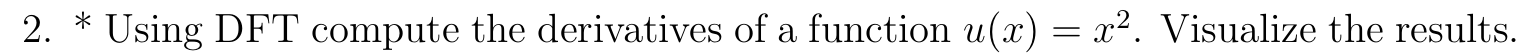

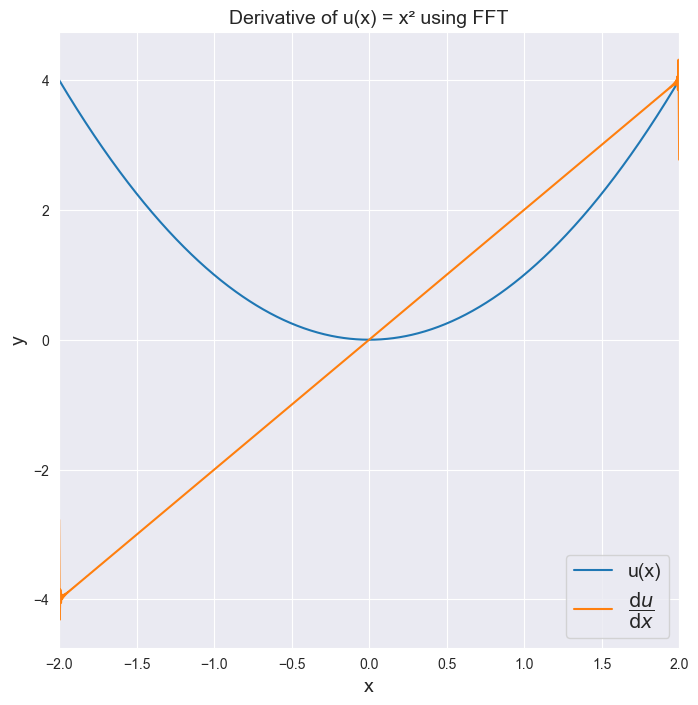

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import diff


L = 2
x = np.linspace(-L, L, 1001)

u = x ** 2

dudx = diff(u, period=2*L)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(x, u, label="u(x)")
ax.plot(x, dudx, label=r"$\dfrac{\mathrm{d}u}{\mathrm{d}x}$")

ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_title("Derivative of u(x) = x² using FFT", fontsize=14)

ax.set_xlim(-L, L)

ax.legend(fontsize=14)

plt.show()

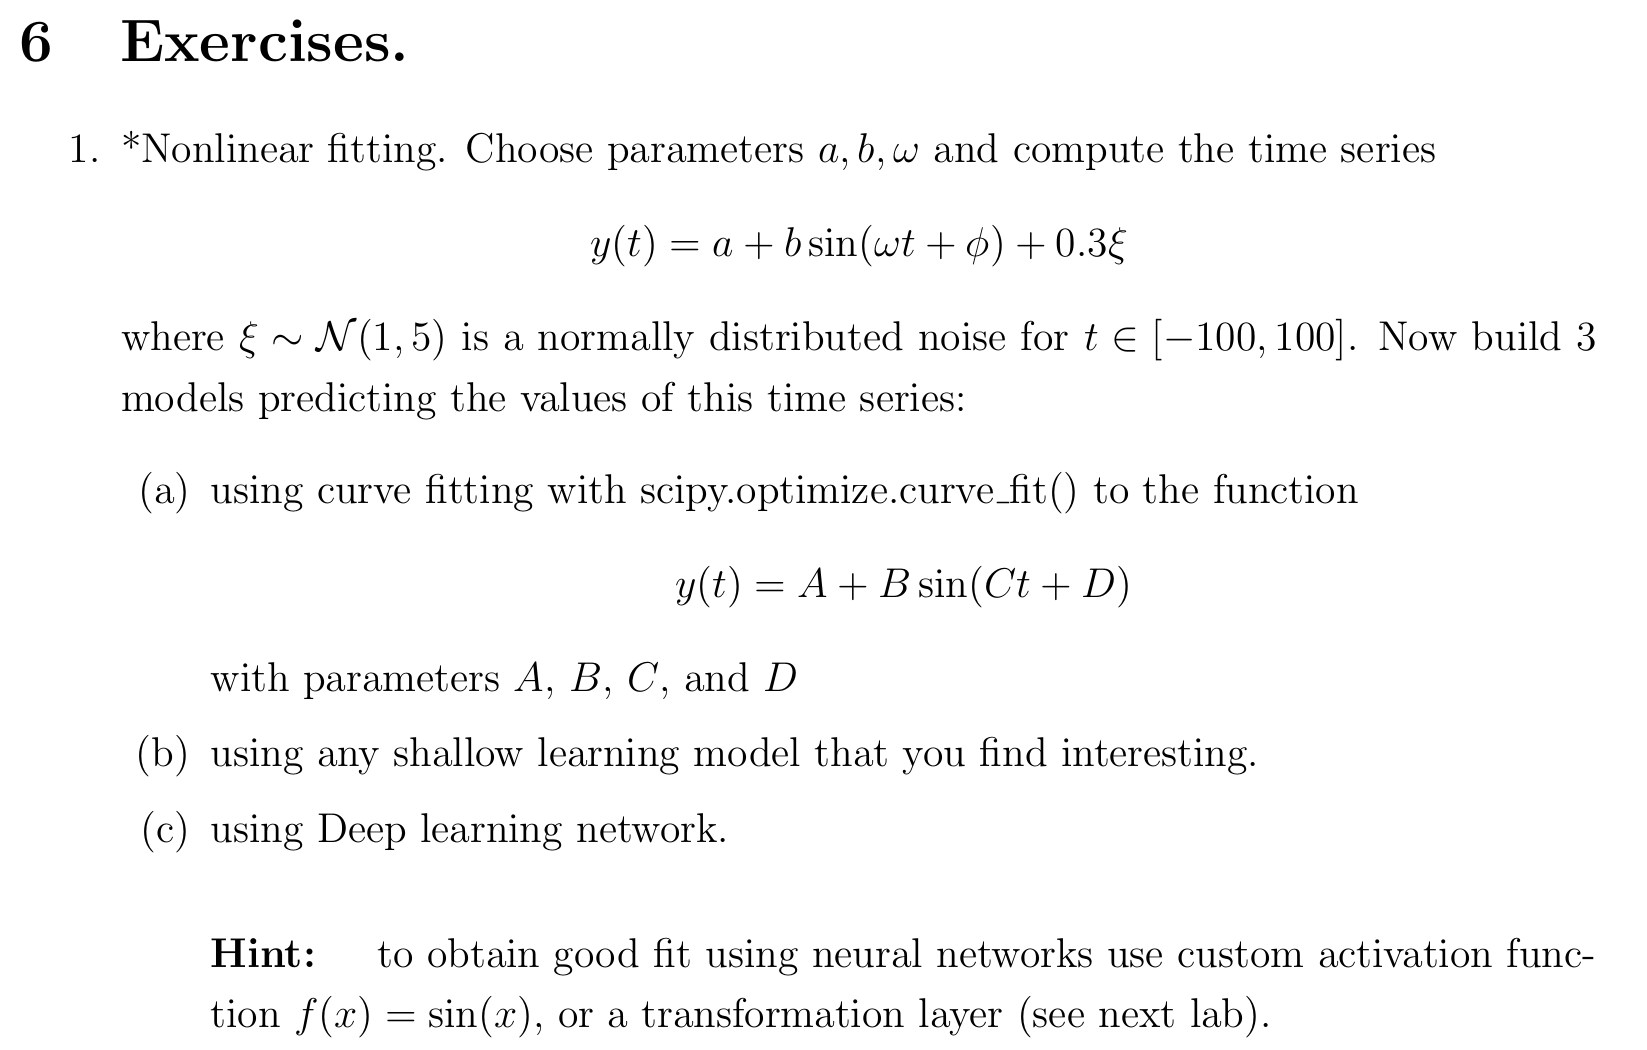

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 328.1115
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 310.5848
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 310.1735
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 312.8170
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 307.9246
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 308.0721
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 309.4426
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 305.7813
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 305.0255
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 303.1072
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 300.3261
Epoch 12/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 295.5376
Epoch 13/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 292.5124
Epoch 14/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 285.8237
Epoch 15/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 

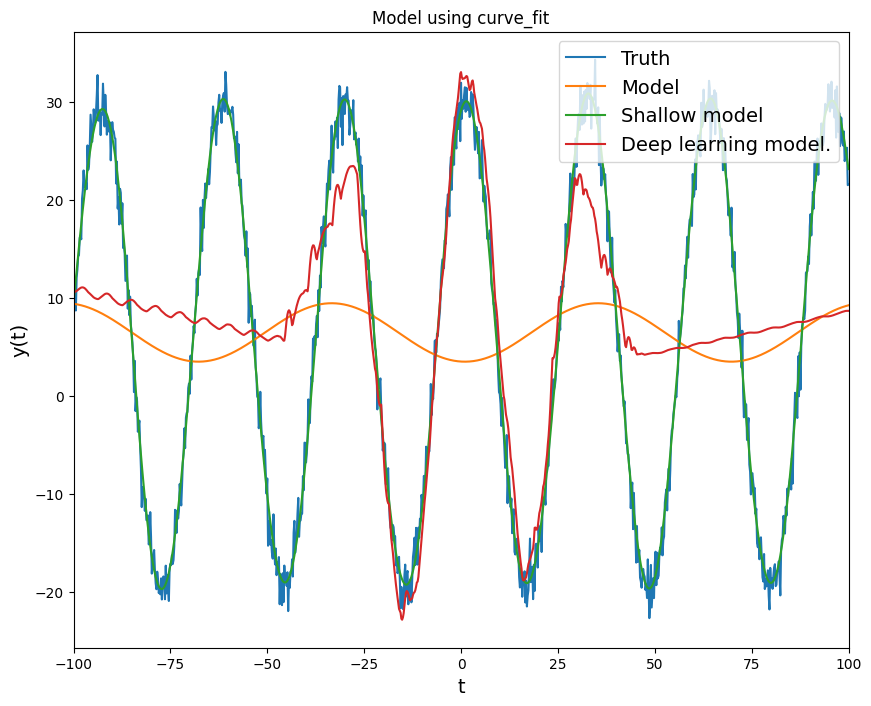

True parameters:
a_true: 5, b_true: 25, c_true: 0.2, d_true: -5.

Predicted parameters using curve_fit:
a_pred: 6.52, b_pred: 2.98, c_pred: 0.09, d_pred: -1.66.

Metrics using Curve fit.

R² = 0.013693010504187697.
MRSE = 17.621648244652604.

Metrics using SVR with test data.

R² = 0.9925830694786132.
MRSE = 1.5740852364897677.

Metrics using SVR with actual data.

R² = 0.9926854640926924.
MRSE = 1.5175180327549478.

Metrics using Deep learning.

R² = 0.3648534566057604.
MRSE = 14.140912724091821.



In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


def show_true_parameters(a_true: float, b_true: float, c_true: float, d_true: float) -> str:
    """Display the true model parameters"""
    print("True parameters:")
    print(f"a_true: {a_true}, b_true: {b_true}, c_true: {c_true}, d_true: {d_true}.\n")


def show_pred_parameters(method: str, a_pred: float, b_pred: float, c_pred: float, d_pred: float):
    """Display the predicted model parameters"""
    print(f"Predicted parameters using {method}:")
    print(f"a_pred: {a_pred:.2f}, b_pred: {b_pred:.2f}, c_pred: {c_pred:.2f}, d_pred: {d_pred:.2f}.\n")


def y_pred(t, A, B , C, D):
    """Curve fitting with scipy.optimize.curve_fit"""
    return A + B * np.sin(C * t + D)


def y_true(t, a, b, c, d):
    """Sine Function"""
    return a + b * np.sin(c * t + d)


def compare_fit(truth: np.ndarray, prediction: np.ndarray, method: str) -> str:
    """Prints a message with the R² score and RMSE for the fit."""
    r2 = r2_score(truth, prediction)
    rmse = root_mean_squared_error(truth, prediction)

    print(f"Metrics using {method}.\n")
    print(f"R² = {r2}.")
    print(f"MRSE = {rmse}.\n")


def sin_activation(x):
    return tf.sin(x)


# Create a random seed for testing reproducibility.
np.random.seed(3)

# Define the true coefficients.
a_true = 5
b_true = 25
c_true = 0.2
d_true = -5


# Create function to be modelled.
size = 1001
tmin, tmax = -100, 100
t  = np.linspace(tmin, tmax, size)
noise = np.random.normal(1, 5, size)
y = y_true(t, a_true, b_true, c_true, d_true) + 0.3*noise

# a) Using scipy.optimize
guess = [2, 25, 0.1, -3]

coefs, _ = curve_fit(
    y_pred,
    t,
    y,
    p0=guess
)

a_pred, b_pred, c_pred, d_pred = coefs
y_model = y_pred(t, a_pred, b_pred, c_pred, d_pred)


# b) Using a shallow learning model.
train_t, test_t, train_y, test_y = train_test_split(
    t.reshape(-1, 1),
    y,
    test_size=0.25,
    random_state=42
)

svr = SVR(
    kernel="rbf",
    C=100,
    gamma=0.01,
    epsilon=0.1
)

svr.fit(train_t, train_y)

y_svr = svr.predict(t.reshape(-1, 1))
y_pred_svr = svr.predict(test_t.reshape(-1, 1))


# c) Using deep learning.
X = np.column_stack([
    np.sin(t),
    np.cos(t),
    t
])

train_X, test_X, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

# Build the network.
model = Sequential([
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

history = model.fit(
    train_X,
    train_y,
    epochs=100,
    verbose=1
)

y_nn = model.predict(X)



# Plotting.
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(t, y, label="Truth")
ax.plot(t, y_model, label="Model")
ax.plot(t, y_svr, label="Shallow model")
ax.plot(t, y_nn, label="Deep learning model.")

ax.set_xlabel("t", fontsize=14)
ax.set_ylabel("y(t)", fontsize=14)
ax.set_title("Model using curve_fit")

ax.set_xlim(tmin, tmax)

ax.legend(loc="upper right", fontsize=14)

plt.show()


# CLI.
show_true_parameters(a_true, b_true, c_true, d_true)
show_pred_parameters("curve_fit", a_pred, b_pred, c_pred, d_pred)

compare_fit(y, y_model, "Curve fit")
compare_fit(test_y, y_pred_svr, "SVR with test data")
compare_fit(y, y_svr, "SVR with actual data")
compare_fit(y, y_nn, "Deep learning")

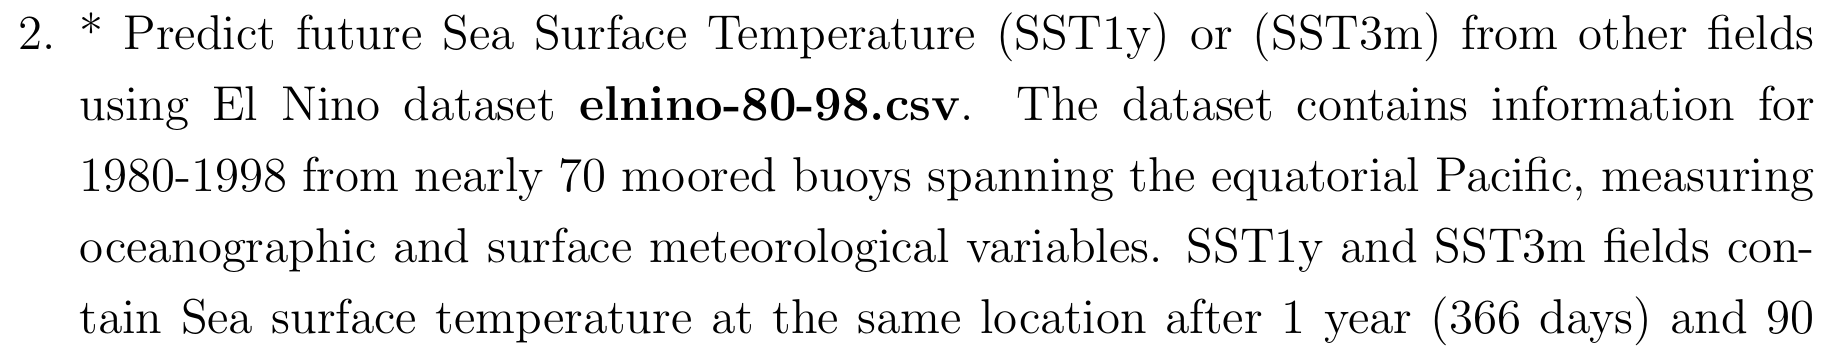
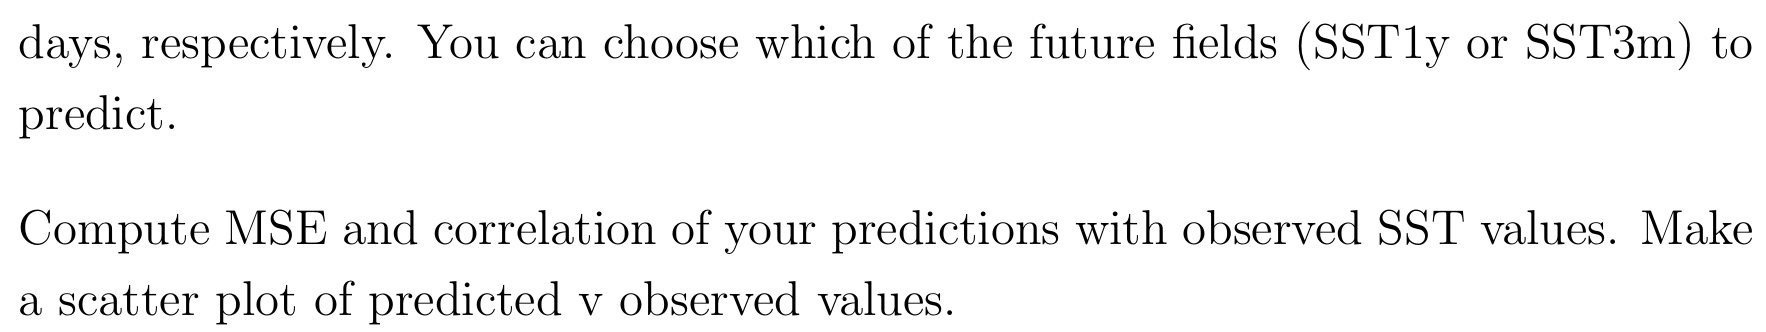

elnino-80-98.csv successfully loaded.
Rows dropped and get_dummies successful.
Imputating successful using the strategy mean.
Random Forest Regressor model model successful.

Training score: 0.8775635742172399
Testing score: 0.8690313768210006
Root Mean Squared Error: 0.735731931415757.
R² Score: 0.8690313768210006.


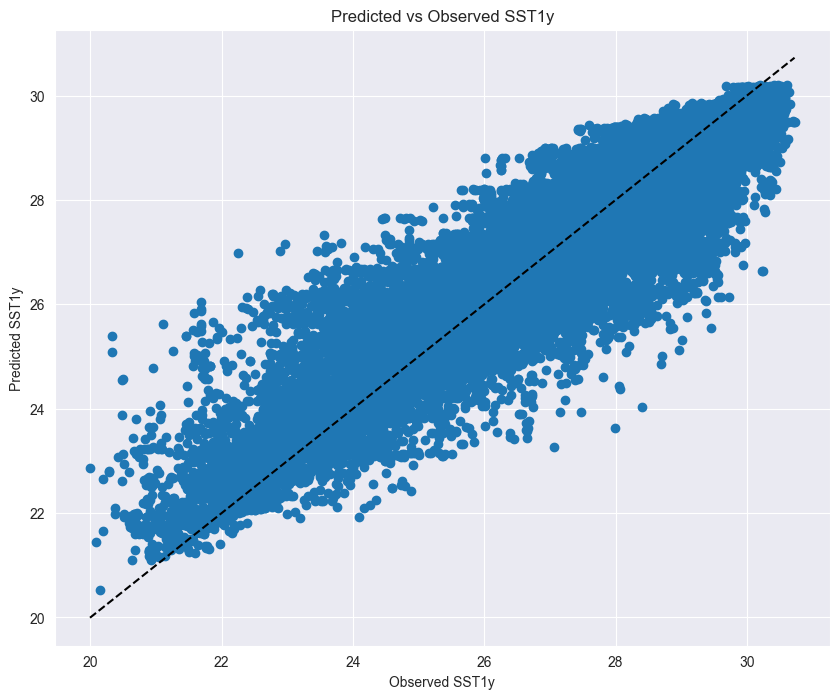

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


data_path = Path("elnino-80-98.csv")

df = pd.read_csv(data_path)

print(f"{data_path} successfully loaded.")

# Drop rows with missing "SST1y".
df1 = df.dropna(subset=["SST1y"])

Y = df1["SST1y"]

df1 = df1.drop(["Observation", "Year", "Month", "Day", "Date", "Meridional_Winds", "SST1y", "SST3m"], axis=1)

X1 = pd.get_dummies(df1)

print("Rows dropped and get_dummies successful.")


# Replace missing values with the mean.
strategy = "mean"
imp = SimpleImputer(missing_values=np.nan, strategy=strategy)
X = imp.fit_transform(X1)

print(f"Imputating successful using the strategy {strategy}.")


# Train the model.
train_X, test_X, train_Y, test_Y = train_test_split(
    X,
    Y,
    test_size=0.25,
    random_state=42,
)

RF = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

RF.fit(train_X, train_Y)

print("Random Forest Regressor model model successful.")

y_pred = RF.predict(test_X)

print("\nTraining score:", RF.score(train_X,train_Y))
print("Testing score:", RF.score(test_X, test_Y))

rmse = root_mean_squared_error(test_Y, y_pred)
r2 = r2_score(test_Y, y_pred)

print(f"Root Mean Squared Error: {rmse}.")
print(f"R² Score: {r2}.")


# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(test_Y, y_pred)

ax.set_xlabel("Observed SST1y")
ax.set_ylabel("Predicted SST1y")
ax.set_title("Predicted vs Observed SST1y")

ax.plot(
    [test_Y.min(), test_Y.max()],
    [test_Y.min(), test_Y.max()],
    "k--",
    label="1:1 line",
)

plt.show()

In [3]:
df

,Unnamed: 0,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal_Winds,Meridional_Winds,Humidity,Air_Temp,SST,Nino34,SST3m,SST1y
0,0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,NaN,25.672144,25.983514
1,1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,NaN,25.686884,26.035242
2,2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,NaN,25.693414,26.087976
3,3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31,NaN,25.705194,26.144617
4,4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19,NaN,25.714380,26.198969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,178075,178076,98,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14,-0.583995,27.794153,27.038385
178076,178076,178077,98,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87,-0.411151,27.754510,27.078027
178077,178077,178078,98,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93,-0.452528,27.715845,27.117029
178078,178078,178079,98,6,14,980614,8.96,-140.33,-4.9,-2.3,76.2,27.36,28.03,-0.415563,27.677484,27.152155


array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

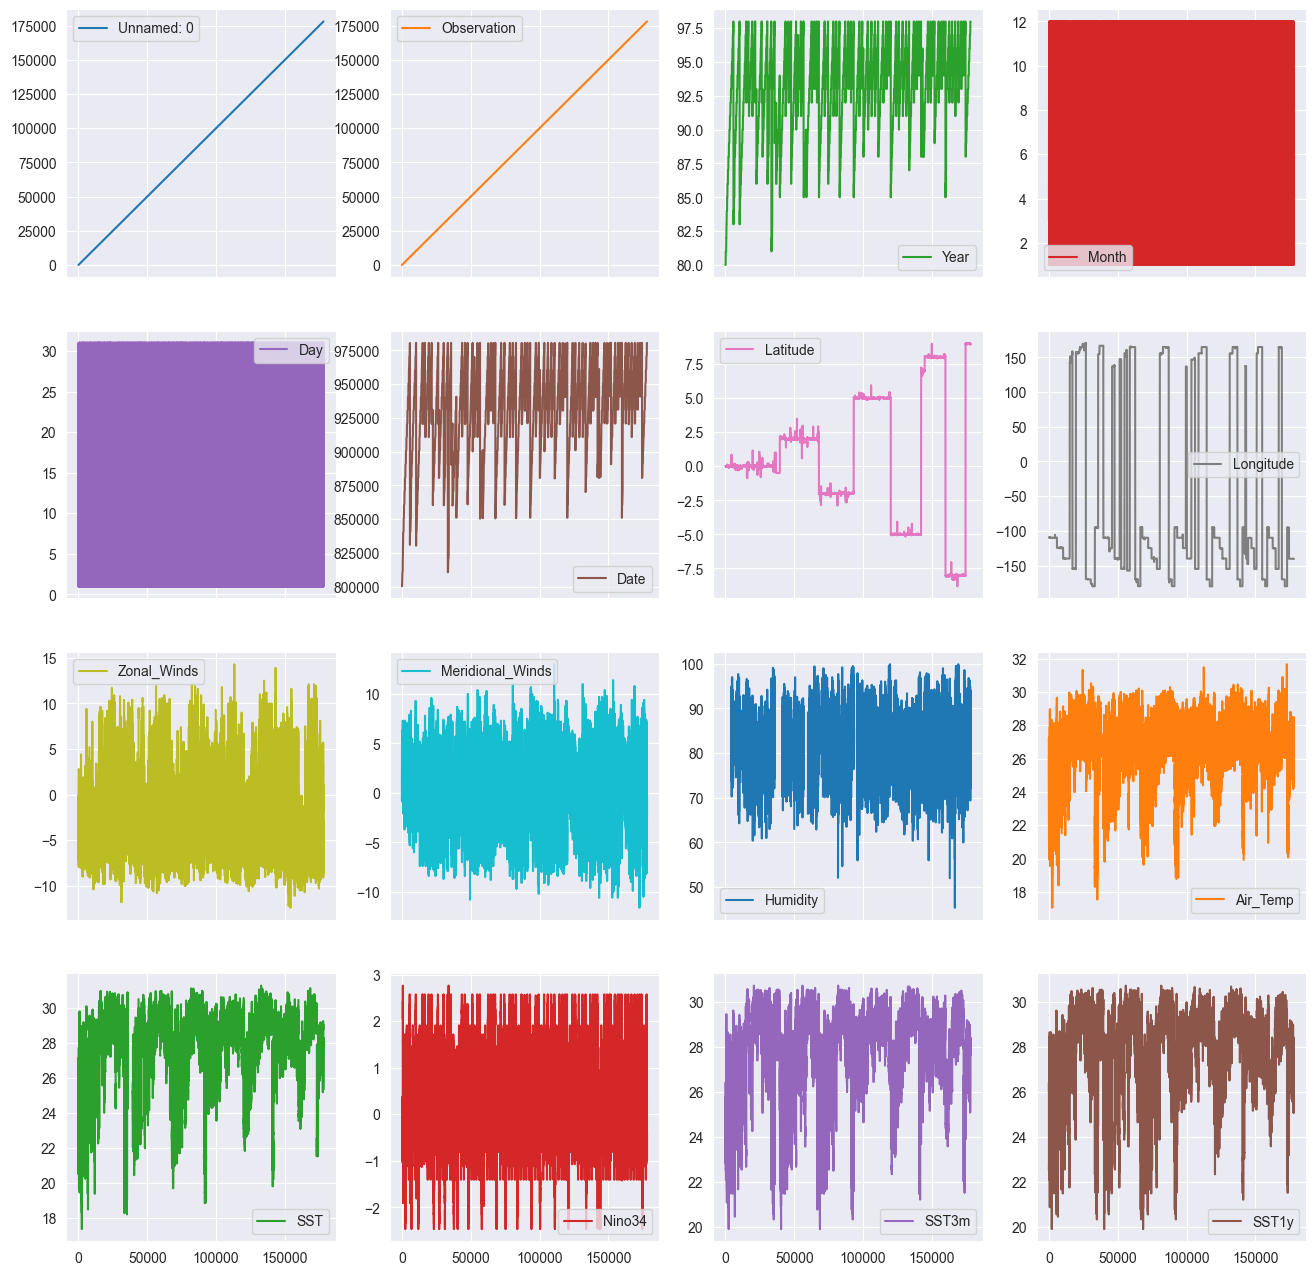

In [5]:
df.describe().T
df.plot(subplots=True, layout=(4,4), figsize=(16, 16))

In [6]:
df

,Unnamed: 0,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal_Winds,Meridional_Winds,Humidity,Air_Temp,SST,Nino34,SST3m,SST1y
0,0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,NaN,25.672144,25.983514
1,1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,NaN,25.686884,26.035242
2,2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,NaN,25.693414,26.087976
3,3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31,NaN,25.705194,26.144617
4,4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19,NaN,25.714380,26.198969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,178075,178076,98,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14,-0.583995,27.794153,27.038385
178076,178076,178077,98,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87,-0.411151,27.754510,27.078027
178077,178077,178078,98,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93,-0.452528,27.715845,27.117029
178078,178078,178079,98,6,14,980614,8.96,-140.33,-4.9,-2.3,76.2,27.36,28.03,-0.415563,27.677484,27.152155


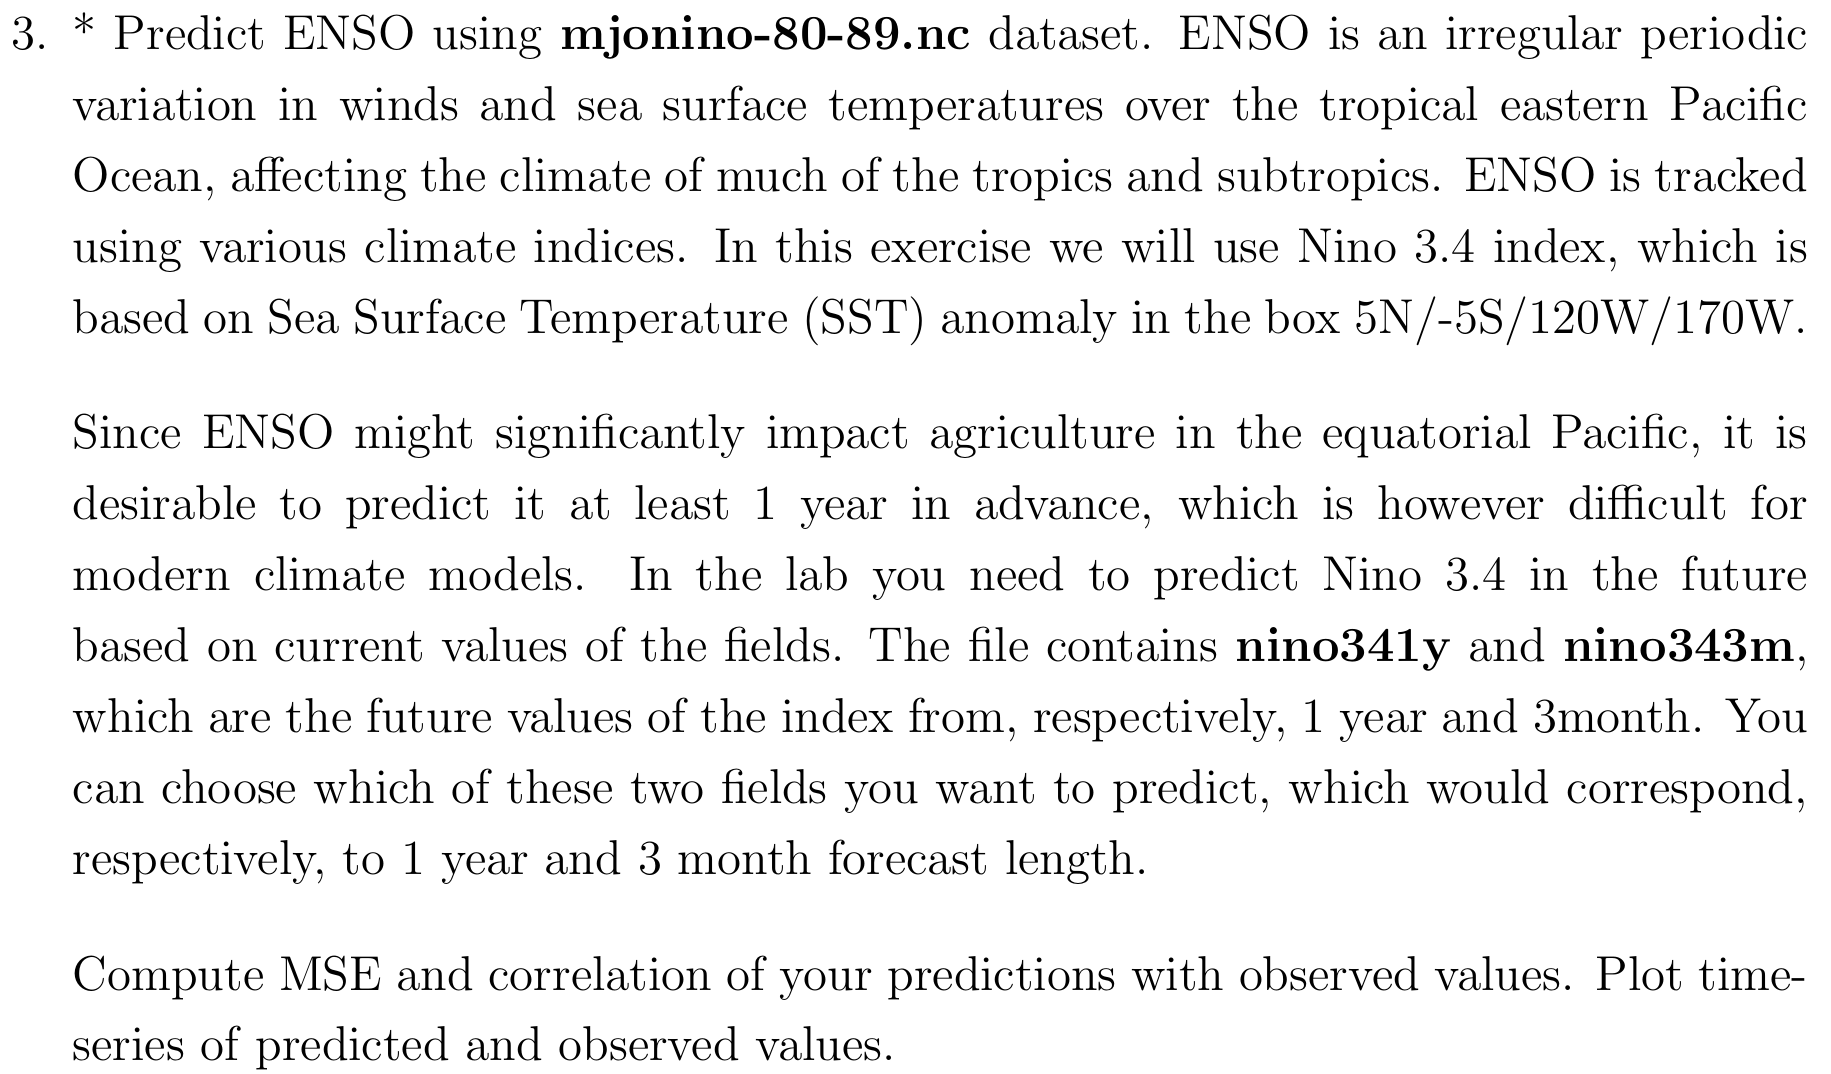